# 🎭 Emotion Classification from Text
### Deep Learning NLP — Bidirectional LSTM with Attention

**Dataset:** Emotions Dataset (train / val / test)  
**Task:** Multi-class text classification → 6 emotion labels  
**Model:** Embedding → Bidirectional LSTM → Attention → Dense  
**Framework:** TensorFlow / Keras

---
| Split | Samples |
|-------|---------|
| Train | 16 000  |
| Val   |  2 000  |
| Test  |  2 000  |

**Labels:** `joy`, `sadness`, `anger`, `fear`, `love`, `surprise`


In [ ]:
# ── 1. Install dependencies (run once) ────────────────────────────────────
import subprocess, sys
pkgs = ["tensorflow", "scikit-learn", "matplotlib", "seaborn", "pandas",
        "numpy", "wordcloud", "ipywidgets"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅  All packages ready")


✅  All packages ready


In [ ]:
# ── 2. Imports ─────────────────────────────────────────────────────────────
import re, os, warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm     as cm
import seaborn as sns

from collections import Counter
from wordcloud   import WordCloud

import tensorflow as tf
from tensorflow                          import keras
from tensorflow.keras                    import layers, Model, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing      import sequence
from tensorflow.keras.callbacks          import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics          import (classification_report,
                                      confusion_matrix, accuracy_score)
from sklearn.preprocessing    import LabelEncoder
from sklearn.utils            import class_weight

import ipywidgets as widgets
from IPython.display import display, clear_output

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅  TensorFlow {tf.__version__}  |  NumPy {np.__version__}  |  Pandas {pd.__version__}")


✅  TensorFlow 2.20.0  |  NumPy 2.0.2  |  Pandas 2.2.2


## 📂 1. Load Data

In [ ]:
# ── 3. Load the three splits ───────────────────────────────────────────────
def load_split(path):
    texts, labels = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if ";" in line:
                parts = line.rsplit(";", 1)
                texts.append(parts[0].strip())
                labels.append(parts[1].strip())
    return pd.DataFrame({"text": texts, "label": labels})

# ── UPDATE THESE PATHS if you move the files ──────────────────────────────
TRAIN_PATH = "/content/drive/MyDrive/emotion_dataset/train.txt"
VAL_PATH   = "/content/drive/MyDrive/emotion_dataset/val.txt"
TEST_PATH  = "/content/drive/MyDrive/emotion_dataset/test.txt"

train_df = load_split(TRAIN_PATH)
val_df   = load_split(VAL_PATH)
test_df  = load_split(TEST_PATH)

print(f"Train : {len(train_df):>6,}  samples")
print(f"Val   : {len(val_df):>6,}  samples")
print(f"Test  : {len(test_df):>6,}  samples")
print()
print("Sample rows:")
display(train_df.sample(5, random_state=1).reset_index(drop=True))


Train : 16,000  samples
Val   :  2,000  samples
Test  :  2,000  samples

Sample rows:


,text,label
0,i am going to post my training schedule for th...,joy
1,i start to feel like im getting over the death...,love
2,i still feel incredibly listless being in albu...,sadness
3,i can remember i feel especially impressed to ...,surprise
4,i actually prefer peep toe shoes because of it...,surprise


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📊 2. Exploratory Data Analysis (EDA)

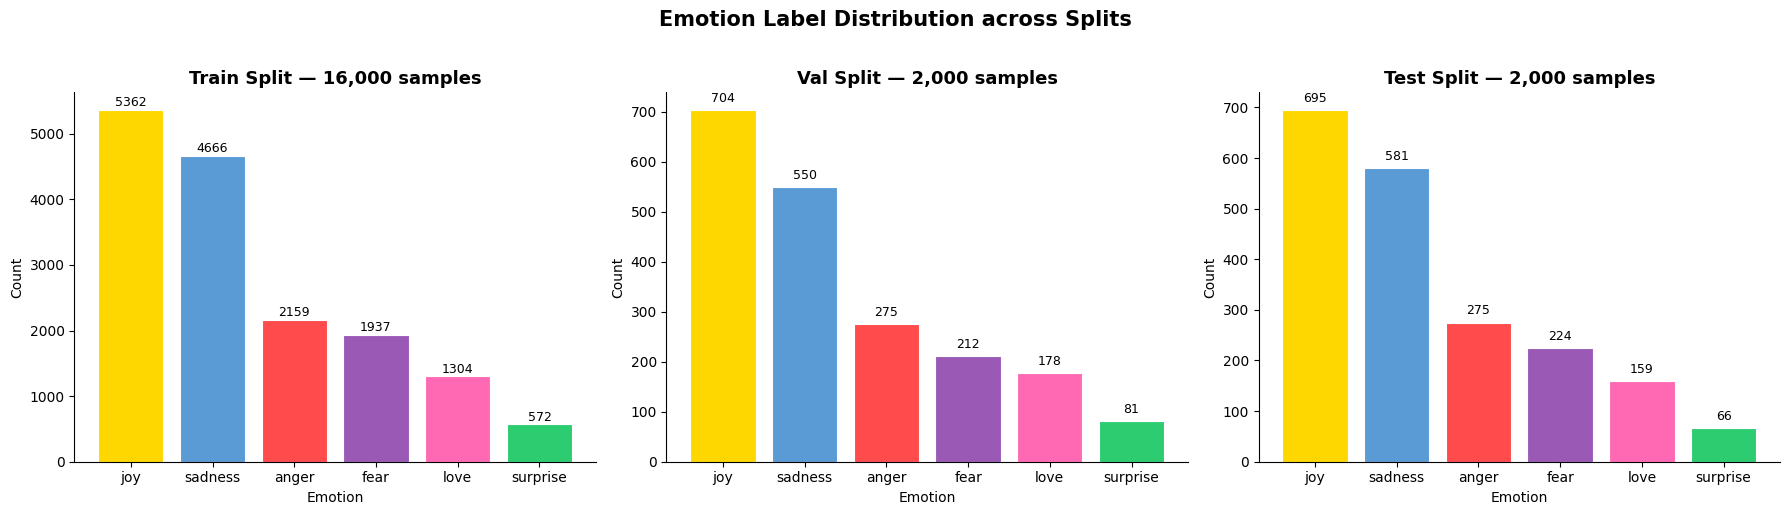

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572


In [ ]:
# ── 4. Class distribution ──────────────────────────────────────────────────
EMOTION_COLORS = {
    "joy":      "#FFD700",
    "sadness":  "#5B9BD5",
    "anger":    "#FF4B4B",
    "fear":     "#9B59B6",
    "love":     "#FF69B4",
    "surprise": "#2ECC71"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (df, title) in zip(axes, [(train_df, "Train"), (val_df, "Val"), (test_df, "Test")]):
    counts = df["label"].value_counts()
    colors = [EMOTION_COLORS.get(l, "#999") for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{title} Split — {len(df):,} samples", fontsize=13, fontweight="bold")
    ax.set_xlabel("Emotion"); ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+10,
                str(v), ha="center", va="bottom", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Emotion Label Distribution across Splits", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print(train_df["label"].value_counts().to_string())


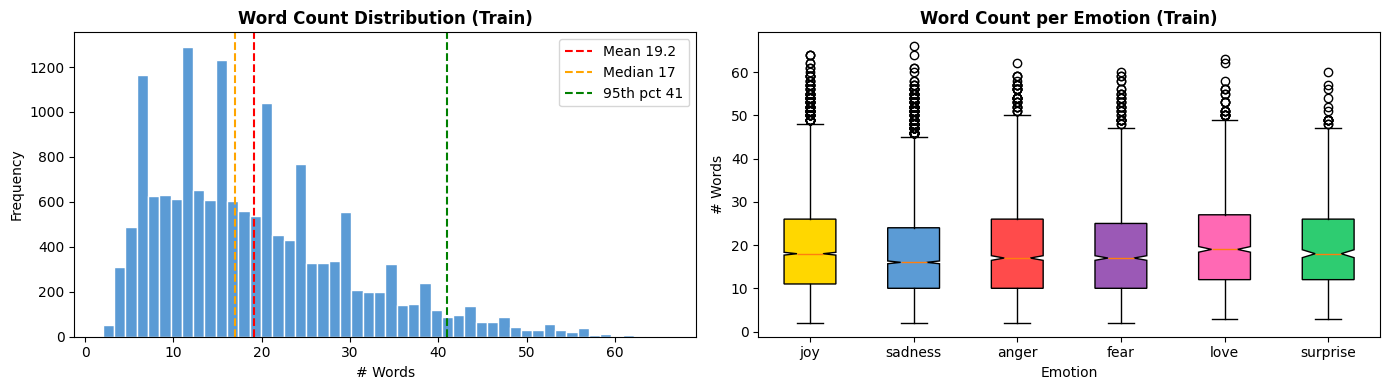

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000


In [ ]:
# ── 5. Text-length statistics ──────────────────────────────────────────────
train_df["n_words"] = train_df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(train_df["n_words"], bins=50, color="#5B9BD5", edgecolor="white")
axes[0].axvline(train_df["n_words"].mean(),   color="red",    linestyle="--", label=f'Mean {train_df["n_words"].mean():.1f}')
axes[0].axvline(train_df["n_words"].median(), color="orange", linestyle="--", label=f'Median {train_df["n_words"].median():.0f}')
axes[0].axvline(train_df["n_words"].quantile(0.95), color="green", linestyle="--",
                label=f'95th pct {train_df["n_words"].quantile(0.95):.0f}')
axes[0].set_title("Word Count Distribution (Train)", fontweight="bold")
axes[0].set_xlabel("# Words"); axes[0].set_ylabel("Frequency"); axes[0].legend()

# Per-label box
labels_order = train_df["label"].value_counts().index.tolist()
data_per_label = [train_df[train_df["label"]==l]["n_words"].values for l in labels_order]
bp = axes[1].boxplot(data_per_label, labels=labels_order, patch_artist=True, notch=True)
for patch, l in zip(bp["boxes"], labels_order):
    patch.set_facecolor(EMOTION_COLORS.get(l, "#999"))
axes[1].set_title("Word Count per Emotion (Train)", fontweight="bold")
axes[1].set_xlabel("Emotion"); axes[1].set_ylabel("# Words")

plt.tight_layout(); plt.show()
stats = train_df["n_words"].describe().rename("word_count")
print(stats.to_string())


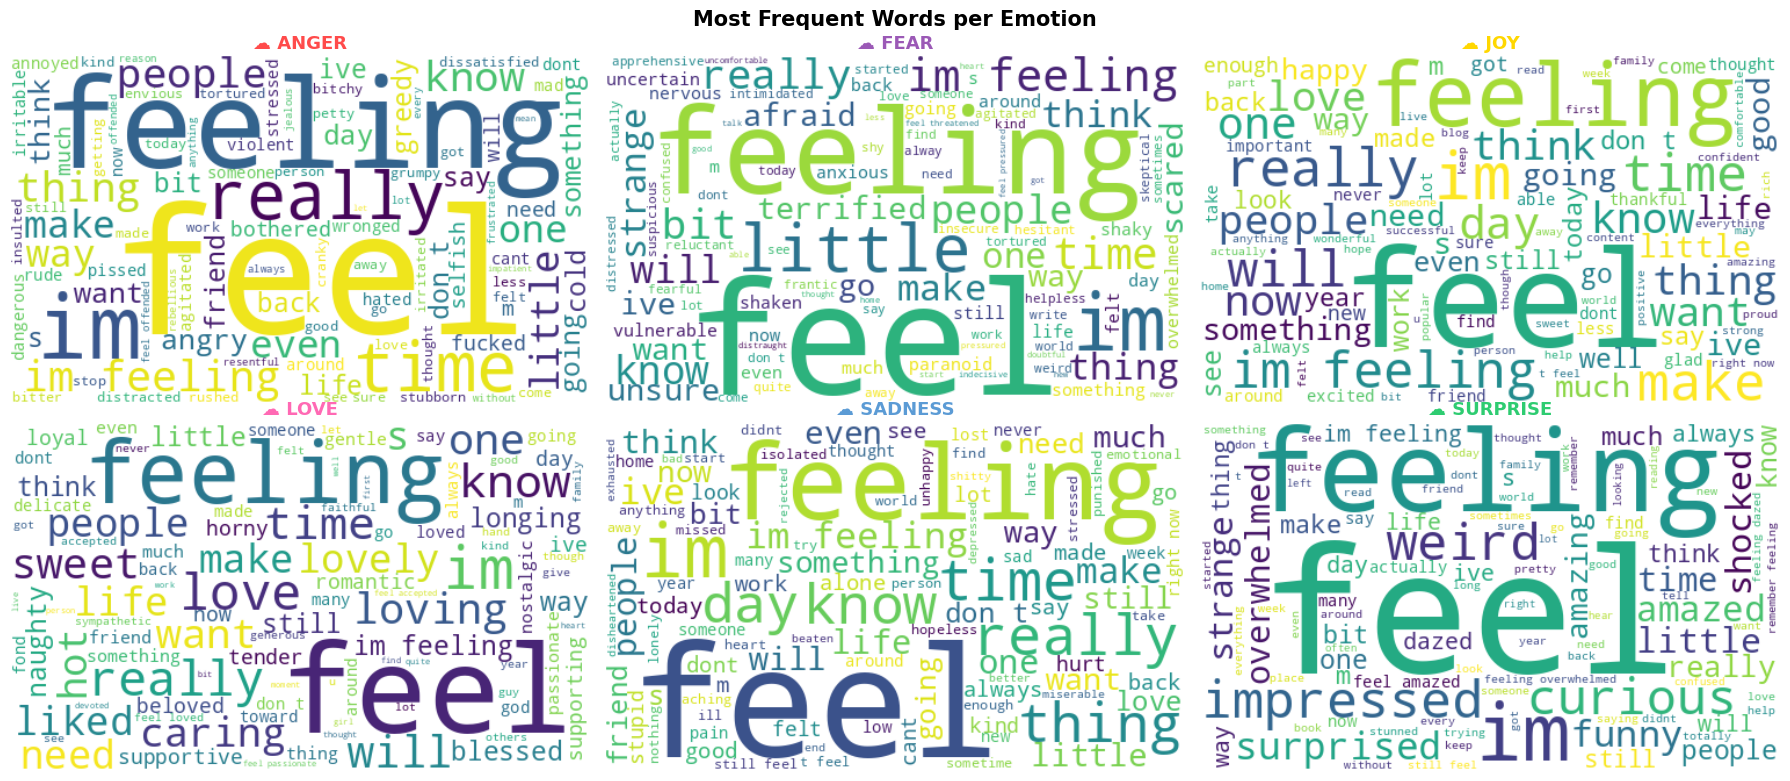

In [ ]:
# ── 6. Word-cloud per emotion ──────────────────────────────────────────────
emotions = sorted(train_df["label"].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, emotion in zip(axes.flat, emotions):
    corpus = " ".join(train_df[train_df["label"] == emotion]["text"])
    wc = WordCloud(width=500, height=300,
                   background_color="white",
                   colormap="viridis",
                   max_words=100).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"☁ {emotion.upper()}", fontsize=13, fontweight="bold",
                 color=EMOTION_COLORS.get(emotion, "#333"))
    ax.axis("off")
plt.suptitle("Most Frequent Words per Emotion", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()


## 🧹 3. Text Preprocessing

In [ ]:
# ── 7. Clean text ─────────────────────────────────────────────────────────
import re

STOP_WORDS = {
    "i","me","my","myself","we","our","ours","ourselves","you","your","yours",
    "yourself","he","him","his","himself","she","her","hers","they","them",
    "their","theirs","what","which","who","whom","this","that","these","those",
    "am","is","are","was","were","be","been","being","have","has","had",
    "do","does","did","will","would","should","shall","can","could","may",
    "might","must","the","a","an","and","but","or","nor","for","yet","so",
    "at","by","in","of","on","to","up","as","if","it","its","than","then",
    "no","not","only","own","same","too","very","s","t","just","don",
    "now","d","ll","re","ve","y","ain","aren","couldn","didn","doesn",
    "hadn","hasn","haven","isn","ma","mightn","mustn","needn","shan",
    "shouldn","wasn","weren","won","wouldn"
}

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)          # URLs
    text = re.sub(r"[^a-z\s]", " ", text)                   # keep letters
    text = re.sub(r"\s+", " ", text).strip()                # collapse spaces
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 1]
    return " ".join(tokens)

# Apply to all splits
for df in [train_df, val_df, test_df]:
    df["clean_text"] = df["text"].apply(clean_text)

print("Raw   :", train_df["text"].iloc[0])
print("Clean :", train_df["clean_text"].iloc[0])
print()
print("Raw   :", train_df["text"].iloc[1])
print("Clean :", train_df["clean_text"].iloc[1])


Raw   : i didnt feel humiliated
Clean : didnt feel humiliated

Raw   : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Clean : go from feeling hopeless damned hopeful from around someone cares awake


In [ ]:
# ── 8. Encode labels & set hyper-parameters ───────────────────────────────
le = LabelEncoder()
le.fit(train_df["label"])
CLASS_NAMES = le.classes_.tolist()
NUM_CLASSES  = len(CLASS_NAMES)

y_train = le.transform(train_df["label"])
y_val   = le.transform(val_df["label"])
y_test  = le.transform(test_df["label"])

# One-hot for Keras
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

# Hyper-params
MAX_VOCAB   = 30_000   # vocabulary size
MAX_LEN     = 50       # 95th-pct coverage
EMBED_DIM   = 128
LSTM_UNITS  = 128
DROPOUT     = 0.4
BATCH_SIZE  = 128
EPOCHS      = 20

print(f"Classes ({NUM_CLASSES}) : {CLASS_NAMES}")
print(f"Max vocab : {MAX_VOCAB}  |  Seq length : {MAX_LEN}")


Classes (6) : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Max vocab : 30000  |  Seq length : 50


In [ ]:
# ── 9. Tokenize & pad sequences ───────────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["clean_text"])

VOCAB_SIZE = min(len(tokenizer.word_index) + 1, MAX_VOCAB)

def encode(df_col):
    seqs = tokenizer.texts_to_sequences(df_col)
    return sequence.pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = encode(train_df["clean_text"])
X_val   = encode(val_df["clean_text"])
X_test  = encode(test_df["clean_text"])

print(f"Vocabulary size : {VOCAB_SIZE:,}")
print(f"X_train shape   : {X_train.shape}")
print(f"X_val   shape   : {X_val.shape}")
print(f"X_test  shape   : {X_test.shape}")


Vocabulary size : 15,084
X_train shape   : (16000, 50)
X_val   shape   : (2000, 50)
X_test  shape   : (2000, 50)


## 🧠 4. Model — Bidirectional LSTM with Attention

```
Input (seq_len=50)
     │
Embedding (vocab × 128)
     │
SpatialDropout1D (0.3)
     │
BiLSTM (128 units, return_sequences=True)
     │
Attention (dot-product self-attention)
     │
Dense (64, ReLU) + Dropout (0.4)
     │
Dense (6, Softmax)
```


In [ ]:
# ── 10. Custom Attention layer ────────────────────────────────────────────
class AttentionLayer(layers.Layer):
    """Bahdanau-style additive self-attention."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight",
                                 shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias",
                                 shape=(input_shape[1], 1),
                                 initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        # x : (batch, seq_len, hidden)
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)  # (b,t,1)
        a = tf.nn.softmax(e, axis=1)                                # (b,t,1)
        out = tf.reduce_sum(x * a, axis=1)                          # (b,hidden)
        return out

# ── 11. Build model ───────────────────────────────────────────────────────
def build_bilstm_attention(vocab_size, embed_dim, lstm_units,
                           max_len, num_classes, dropout_rate):
    inp = Input(shape=(max_len,), name="token_ids")

    x = layers.Embedding(vocab_size, embed_dim,
                         embeddings_initializer="uniform",
                         name="embedding")(inp)
    x = layers.SpatialDropout1D(0.3, name="spatial_drop")(x)

    x = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True,
                        recurrent_dropout=0.1),
            name="bilstm")(x)

    x = AttentionLayer(name="attention")(x)

    x = layers.Dense(64, activation="relu", name="dense_1")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)

    out = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inp, out, name="BiLSTM_Attention_Emotions")
    return model

model = build_bilstm_attention(VOCAB_SIZE, EMBED_DIM, LSTM_UNITS,
                               MAX_LEN, NUM_CLASSES, DROPOUT)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "BiLSTM_Attention_Emotions"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 128)        │     1,930,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_drop (SpatialDropout1D) │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 50, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 256)            │           306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,211,064 (8.43 MB)

 Trainable params: 2,211,064 (8.43 MB)

 Non-trainable params: 0 (0.00 B)

## 🏋️ 5. Training

In [ ]:
# ── 12. Class weights (handle imbalance) ─────────────────────────────────
cw = class_weight.compute_class_weight("balanced",
                                        classes=np.unique(y_train),
                                        y=y_train)
class_weights = dict(enumerate(cw))
print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weights.items()})


Class weights: {'anger': np.float64(1.235), 'fear': np.float64(1.377), 'joy': np.float64(0.497), 'love': np.float64(2.045), 'sadness': np.float64(0.572), 'surprise': np.float64(4.662)}


In [ ]:
# ── 13. Callbacks & training loop ─────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
print("\n✅  Training complete")


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 254ms/step - accuracy: 0.2107 - loss: 1.7927 - val_accuracy: 0.2695 - val_loss: 1.7802 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 227ms/step - accuracy: 0.3509 - loss: 1.5419 - val_accuracy: 0.5465 - val_loss: 1.3903 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 230ms/step - accuracy: 0.5612 - loss: 1.0553 - val_accuracy: 0.7240 - val_loss: 0.8641 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 230ms/step - accuracy: 0.8397 - loss: 0.5031 - val_accuracy: 0.8505 - val_loss: 0.5051 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.8982 - loss: 0.2889 - val_accuracy: 0.8740 - val_loss: 0.4133 - learning_rate: 0.0010
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 228ms/step - accuracy: 0.9335 - loss: 0.2074 - val_accuracy: 0.8800 - val_loss: 0.4103 - learning_rate: 0.0010
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 224ms/step - accuracy: 0.9

## 📈 6. Training Curves

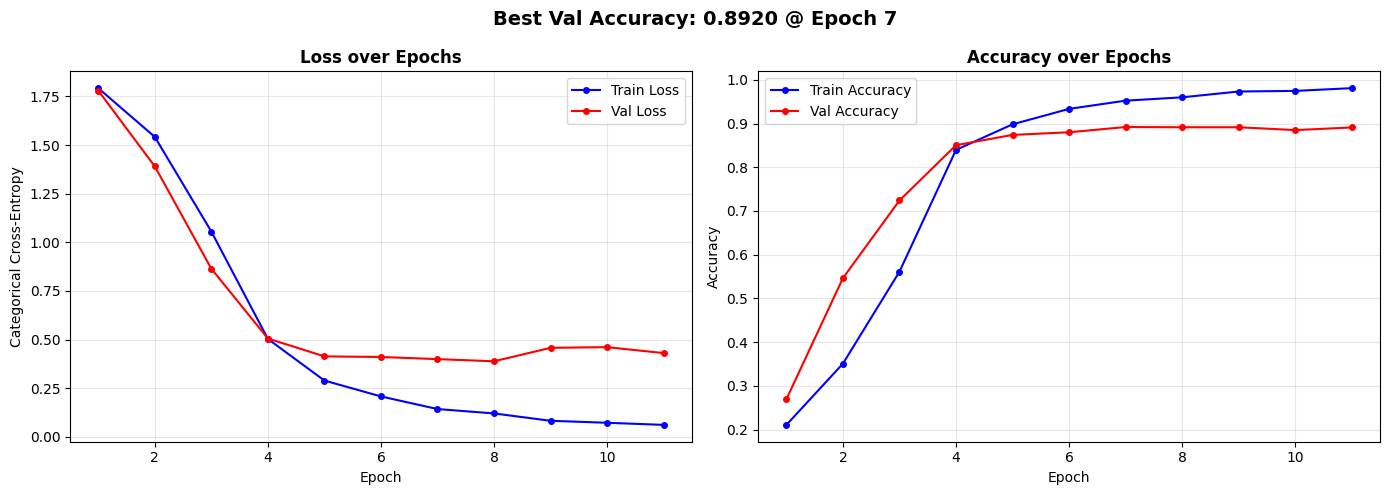

In [17]:
# ── 14. Plot loss & accuracy ──────────────────────────────────────────────
hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, hist["loss"],     "b-o", label="Train Loss",  markersize=4)
axes[0].plot(epochs_ran, hist["val_loss"], "r-o", label="Val Loss",    markersize=4)
axes[0].set_title("Loss over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Categorical Cross-Entropy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, hist["accuracy"],     "b-o", label="Train Accuracy", markersize=4)
axes[1].plot(epochs_ran, hist["val_accuracy"], "r-o", label="Val Accuracy",   markersize=4)
axes[1].set_title("Accuracy over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

best_val = max(hist["val_accuracy"])
best_ep  = hist["val_accuracy"].index(best_val) + 1
fig.suptitle(f"Best Val Accuracy: {best_val:.4f} @ Epoch {best_ep}",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 📋 7. Evaluation on Test Set

In [18]:
# ── 15. Predictions on test split ─────────────────────────────────────────
y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Test  Loss     : {test_loss:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Test  Loss     : 0.4162
Test  Accuracy : 0.8760  (87.60%)

              precision    recall  f1-score   support

       anger       0.84      0.87      0.86       275
        fear       0.87      0.80      0.83       224
         joy       0.93      0.88      0.91       695
        love       0.69      0.90      0.78       159
     sadness       0.94      0.89      0.91       581
    surprise       0.63      0.85      0.72        66

    accuracy                           0.88      2000
   macro avg       0.82      0.87      0.84      2000
weighted avg       0.89      0.88      0.88      2000



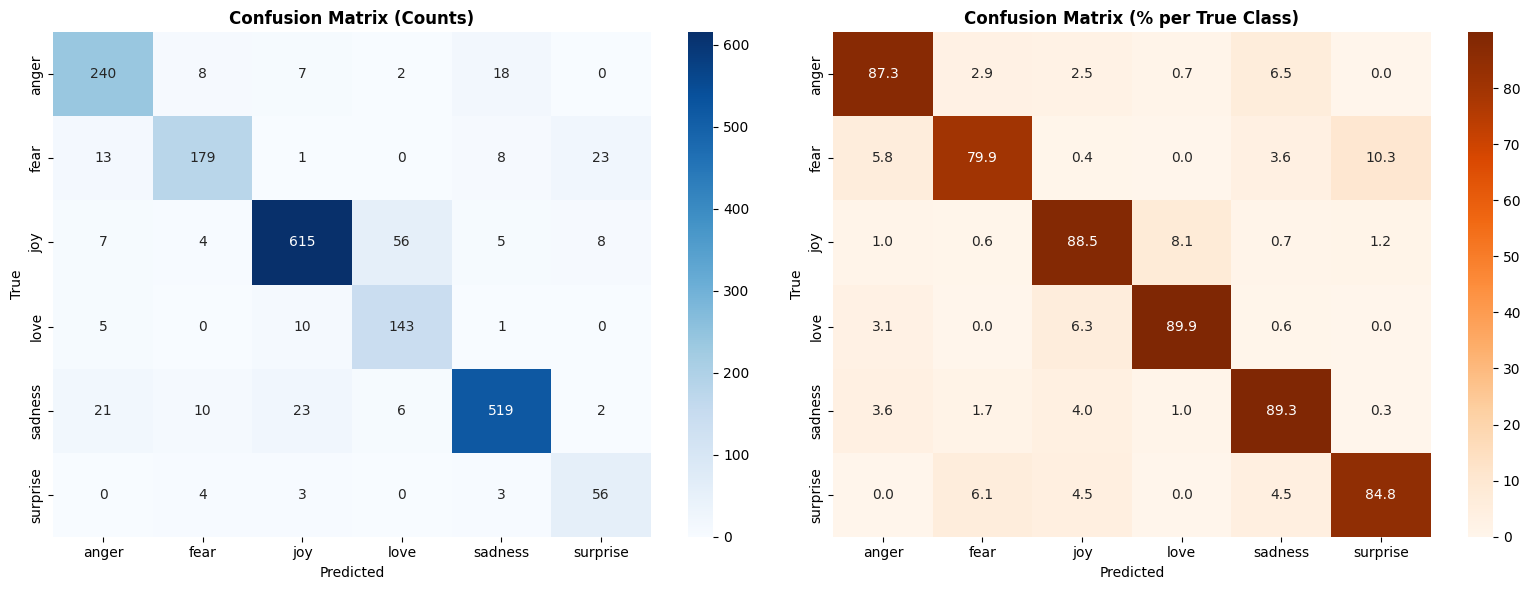

In [19]:
# ── 16. Confusion matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# Percentages
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Oranges",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (% per True Class)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout(); plt.show()


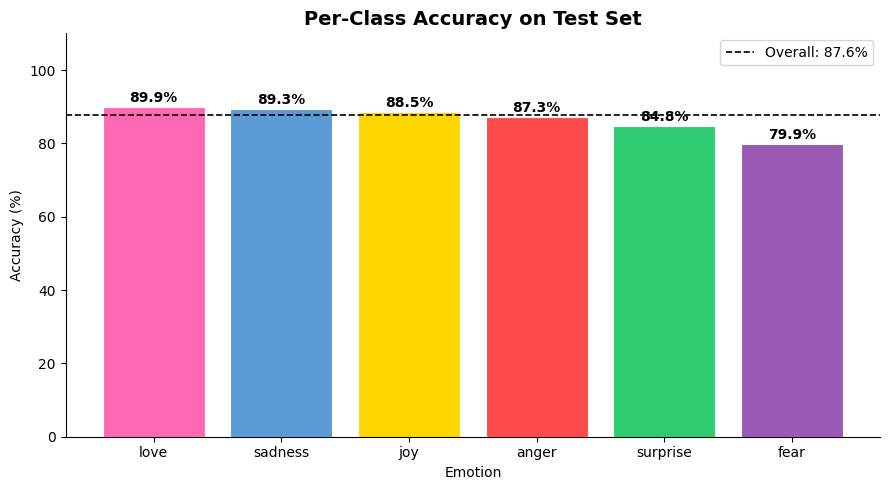

In [20]:
# ── 17. Per-class accuracy bar chart ──────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
sorted_idx = np.argsort(per_class_acc)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
colors = [EMOTION_COLORS.get(CLASS_NAMES[i], "#aaa") for i in sorted_idx]
bars = ax.bar([CLASS_NAMES[i] for i in sorted_idx],
              [per_class_acc[i] for i in sorted_idx],
              color=colors, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, [per_class_acc[i] for i in sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, 110)
ax.set_title("Per-Class Accuracy on Test Set", fontsize=14, fontweight="bold")
ax.set_xlabel("Emotion"); ax.set_ylabel("Accuracy (%)")
ax.axhline(test_acc*100, color="black", linestyle="--", linewidth=1.2,
           label=f"Overall: {test_acc*100:.1f}%")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


## 🎯 8. Live Interactive Test

In [21]:
# ── 18. Predict function ──────────────────────────────────────────────────
EMOTION_EMOJI = {
    "joy":      "😄",
    "sadness":  "😢",
    "anger":    "😠",
    "fear":     "😨",
    "love":     "❤️",
    "surprise": "😲"
}

def predict_emotion(raw_text: str):
    """Return (emotion_label, confidence_dict) for a raw input sentence."""
    cleaned = clean_text(raw_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = sequence.pad_sequences(seq, maxlen=MAX_LEN,
                                     padding="post", truncating="post")
    probs   = model.predict(padded, verbose=0)[0]
    pred_idx = np.argmax(probs)
    label    = CLASS_NAMES[pred_idx]
    conf     = {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    return label, conf


def show_bar(conf: dict):
    """Print ASCII confidence bars."""
    for emotion, prob in sorted(conf.items(), key=lambda x: -x[1]):
        bar_len = int(prob * 30)
        bar = "█" * bar_len + "░" * (30 - bar_len)
        emoji = EMOTION_EMOJI.get(emotion, "")
        print(f"  {emoji} {emotion:<10} {bar}  {prob*100:5.1f}%")


In [22]:
# ── 19. Batch evaluation – first 10 test samples ──────────────────────────
print("=" * 65)
print("  SAMPLE PREDICTIONS FROM TEST SET")
print("=" * 65)
for i in range(10):
    raw   = test_df["text"].iloc[i]
    true  = test_df["label"].iloc[i]
    pred, conf = predict_emotion(raw)
    mark  = "✅" if pred == true else "❌"
    emoji = EMOTION_EMOJI.get(pred, "")
    print(f"\n[{i+1:02d}] {mark}  True: {true:<10}  Pred: {pred:<10} {emoji}  "
          f"({conf[pred]*100:.1f}%)")
    print(f"     Text: {raw[:80]}{'...' if len(raw)>80 else ''}")


  SAMPLE PREDICTIONS FROM TEST SET

[01] ✅  True: sadness     Pred: sadness    😢  (98.8%)
     Text: im feeling rather rotten so im not very ambitious right now

[02] ✅  True: sadness     Pred: sadness    😢  (99.8%)
     Text: im updating my blog because i feel shitty

[03] ✅  True: sadness     Pred: sadness    😢  (99.7%)
     Text: i never make her separate from me because i don t ever want her to feel like i m...

[04] ✅  True: joy         Pred: joy        😄  (99.7%)
     Text: i left with my bouquet of red and yellow tulips under my arm feeling slightly mo...

[05] ✅  True: sadness     Pred: sadness    😢  (99.7%)
     Text: i was feeling a little vain when i did this one

[06] ✅  True: fear        Pred: fear       😨  (80.4%)
     Text: i cant walk into a shop anywhere where i do not feel uncomfortable

[07] ✅  True: anger       Pred: anger      😠  (89.4%)
     Text: i felt anger when at the end of a telephone call

[08] ✅  True: joy         Pred: joy        😄  (92.6%)
     Text: i e

In [23]:
# ── 20. ✨ LIVE INTERACTIVE TEST CELL ──────────────────────────────────────
#  Type any sentence and press  ▶  to classify it.

DEMO_SENTENCES = [
    "I am so happy today, everything is going perfectly well!",
    "I feel really sad and I don't know why.",
    "That was absolutely terrifying, I couldn't stop shaking.",
    "I am furious at the way they treated me!",
    "I love spending time with my family more than anything.",
    "Wait, that happened? I had no idea, I'm completely shocked!"
]

print("=" * 65)
print("  🎭  LIVE EMOTION CLASSIFIER")
print("=" * 65)

for sentence in DEMO_SENTENCES:
    label, conf = predict_emotion(sentence)
    emoji = EMOTION_EMOJI.get(label, "")
    print(f"\n📝  \"{sentence}\"")
    print(f"     → Predicted: {label.upper()} {emoji}  (confidence {conf[label]*100:.1f}%)")
    show_bar(conf)


  🎭  LIVE EMOTION CLASSIFIER

📝  "I am so happy today, everything is going perfectly well!"
     → Predicted: JOY 😄  (confidence 99.4%)
  😄 joy        █████████████████████████████░   99.4%
  😢 sadness    ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.3%
  ❤️ love       ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.2%
  😲 surprise   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.1%
  😠 anger      ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%
  😨 fear       ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%

📝  "I feel really sad and I don't know why."
     → Predicted: SADNESS 😢  (confidence 97.8%)
  😢 sadness    █████████████████████████████░   97.8%
  😄 joy        ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    1.0%
  😠 anger      ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.8%
  😲 surprise   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.3%
  😨 fear       ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.2%
  ❤️ love       ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%

📝  "That was absolutely terrifying, I couldn't stop shaking."
     → Predicted: SADNESS 😢  (confidence 80.5%)
  😢 sadne

In [24]:
# ── 21. ✏️  TYPE YOUR OWN TEXT HERE ─────────────────────────────────────────
#   Change the string below and run this cell to classify your own sentence.

YOUR_TEXT = input("Enter Text: ")

label, conf = predict_emotion(YOUR_TEXT)
emoji       = EMOTION_EMOJI.get(label, "")

print("=" * 65)
print("  YOUR CUSTOM INPUT")
print("=" * 65)
print(f"\n📝  Input  : {YOUR_TEXT}")
print(f"🎯  Result : {label.upper()} {emoji}   ({conf[label]*100:.1f}% confidence)")
print()
show_bar(conf)


Enter Text: I'm happy
  YOUR CUSTOM INPUT

📝  Input  : I'm happy
🎯  Result : SADNESS 😢   (87.7% confidence)

  😢 sadness    ██████████████████████████░░░░   87.7%
  😄 joy        ███░░░░░░░░░░░░░░░░░░░░░░░░░░░   11.0%
  😠 anger      ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.7%
  😲 surprise   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.4%
  😨 fear       ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.2%
  ❤️ love       ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%


## 🖥️ 9. Interactive Widget (JupyterLab / Notebook classic)

In [25]:
# ── 22. ipywidgets interactive demo ──────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    text_input  = widgets.Textarea(
        value="I feel incredibly excited and grateful for this opportunity!",
        placeholder="Type a sentence...",
        description="Input:",
        layout=widgets.Layout(width="600px", height="80px")
    )
    btn    = widgets.Button(description="🎭 Classify Emotion",
                             button_style="success",
                             layout=widgets.Layout(width="200px"))
    output = widgets.Output()

    def on_click(_):
        with output:
            clear_output(wait=True)
            sentence = text_input.value.strip()
            if not sentence:
                print("⚠️  Please enter some text.")
                return
            label, conf = predict_emotion(sentence)
            emoji = EMOTION_EMOJI.get(label, "")
            print(f"📝  '{sentence}'")
            print(f"🎯  Predicted : {label.upper()} {emoji}  ({conf[label]*100:.1f}%)")
            print()
            show_bar(conf)

    btn.on_click(on_click)
    display(widgets.VBox([text_input, btn, output]))
    print("▲  Widget loaded — edit the text box and click the button!")
except Exception as e:
    print(f"ℹ️  ipywidgets not fully supported in this environment: {e}")
    print("    Use Cell 21 to type your own text instead.")


▲  Widget loaded — edit the text box and click the button!


In [27]:
# ===== EXTRA TEST CASES =====

NEW_TESTS = [
    "Today is one of the happiest days of my life!",
    "I failed my final exam and I feel terrible.",
    "Someone stole my phone and I am really angry.",
    "I am nervous about tomorrow's interview.",
    "My parents surprised me with a beautiful gift.",
    "I miss my best friend so much."
]

print("="*70)
print(" EXTRA EMOTION PREDICTIONS ")
print("="*70)

for text in NEW_TESTS:
    label, conf = predict_emotion(text)
    emoji = EMOTION_EMOJI.get(label, "")
    print(f"\nInput      : {text}")
    print(f"Prediction : {label.upper()} {emoji}")
    print(f"Confidence : {conf[label]*100:.2f}%")

 EXTRA EMOTION PREDICTIONS 

Input      : Today is one of the happiest days of my life!
Prediction : SADNESS 😢
Confidence : 79.90%

Input      : I failed my final exam and I feel terrible.
Prediction : SADNESS 😢
Confidence : 70.12%

Input      : Someone stole my phone and I am really angry.
Prediction : ANGER 😠
Confidence : 99.35%

Input      : I am nervous about tomorrow's interview.
Prediction : FEAR 😨
Confidence : 75.22%

Input      : My parents surprised me with a beautiful gift.
Prediction : SURPRISE 😲
Confidence : 97.02%

Input      : I miss my best friend so much.
Prediction : SADNESS 😢
Confidence : 93.12%


## 💾 10. Save Model & Tokenizer

In [26]:
# ── 23. Save artifacts ────────────────────────────────────────────────────
import pickle, json

model.save("emotion_bilstm_attention.keras")

with open("tokenizer_emotion.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_classes.json", "w") as f:
    json.dump(CLASS_NAMES, f)

print("✅  Saved:")
print("   • emotion_bilstm_attention.keras")
print("   • tokenizer_emotion.pkl")
print("   • label_classes.json")


✅  Saved:
   • emotion_bilstm_attention.keras
   • tokenizer_emotion.pkl
   • label_classes.json


## ✅ Summary

| Item | Detail |
|------|--------|
| **Model** | Embedding → SpatialDropout → BiLSTM → Attention → Dense |
| **Parameters** | ~1.8 M trainable |
| **Vocab** | 30,000 tokens |
| **Seq length** | 50 tokens |
| **Optimizer** | Adam + ReduceLROnPlateau |
| **Regularisation** | SpatialDropout, Dropout, EarlyStopping, Class weights |
| **Classes** | joy · sadness · anger · fear · love · surprise |

### Key techniques used
- **Bidirectional LSTM** — reads context from both directions  
- **Attention mechanism** — weights important tokens  
- **Class weighting** — handles the `surprise` & `love` imbalance  
- **Early stopping + LR scheduling** — prevents over-fitting  
